# DH Final Diagnostics — 20260714_v1990 (post-2000 final grid)

Final-selection notebook for the **256-config final grid** at
`02-evaluate/20260714_v1990_final/` (model_predictions pending — initial run used --skip-model-predictions; the trimmed-ratio / IS-OOS section needs the no-skip rerun). Fork of
`20260515/dh_final_diagnostics_post2000.ipynb`, repointed at the new
re-fit-pipeline run.

The storm-level machinery here — `mid` reconstruction → per-row prediction
loaders → drop-top-N trimmed calibration → IS/OOS divergence → picking table —
is the point of this stage: it arbitrates the winner where the aggregate
ranking can't. (The refined ranking favoured configs pinned at the
calibration-gate floor, i.e. heavy aggregate under-prediction; trimmed,
storm-level calibration is what separates them.)

**Convergence gate removed:** the re-fit-in-evaluate pipeline has no fit stage
and writes no per-component `.json` sidecars, so that gate (present in the
20260517 version) is dropped.


In [26]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from idd_tc_mortality.select.model_query import ModelQuery
from idd_tc_mortality.select.model_selection import (
    CONFIG_COLS,
    DEFAULT_METRICS,
    CALIBRATION_METRICS,
    prepare_rankings_df,
    borda_rank,
    pareto_frontier,
    topsis_rank,
    pairwise_dominance_summary,
    cluster_configurations,
    winner_profile,
    kendall_tau_heatmap,
    prune_redundant_metrics
)
from idd_tc_mortality.viz.stage_plots import StagePlotter

# Reuse the qmd's helper module for shared heatmap / winner-panel plots.
sys.path.insert(0, str(Path('../..').resolve() / 'reports'))
import _helpers as H

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
pd.options.display.max_columns = 80
pd.options.display.width = 160

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Paths

Edit the dates to point at the refined run you want to inspect.

In [27]:
ROOT      = Path('/mnt/team/idd/pub/idd_tc_mortality')
EVAL_DATE = '20260714_v1990_final'   # 4,608-config final-grid evaluate dir
DATA_DATE = '20260714_v1990'         # post-2000 input.parquet (years >= 2000)

RESULTS_PATH   = ROOT / '02-evaluate' / EVAL_DATE / 'dh_results.parquet'
EVAL_DIR       = ROOT / '02-evaluate' / EVAL_DATE
DATA_PATH      = ROOT / '00-data'     / DATA_DATE / 'input.parquet'
MODEL_PRED_DIR = EVAL_DIR / 'model_predictions'
# Re-fit pipeline writes the manifest into the evaluate dir (no separate fit stage).
MANIFEST_PATH  = EVAL_DIR / 'manifest.json'

for p in (RESULTS_PATH, EVAL_DIR, DATA_PATH, MODEL_PRED_DIR, MANIFEST_PATH):
    assert p.exists(), f'Missing: {p}'
print('All paths resolve.')
print(f'  model_predictions parquets: {len(list(MODEL_PRED_DIR.glob("*.parquet")))}')


All paths resolve.
  model_predictions parquets: 27648


## Load

In [28]:
dh_results = pd.read_parquet(RESULTS_PATH)
data       = pd.read_parquet(DATA_PATH)

print(f'dh_results : {dh_results.shape[0]:,} rows × {dh_results.shape[1]} cols')
print(f'training   : {data.shape[0]:,} rows × {data.shape[1]} cols')
print(f'fold_tags  : {dh_results["fold_tag"].value_counts().to_dict()}')
print(f'configs    : {dh_results.groupby(CONFIG_COLS, dropna=False).ngroups:,} unique')
print(f'thresholds : {sorted(dh_results["threshold_quantile"].unique())}')

dh_results : 27,648 rows × 252 cols
training   : 2,658 rows × 13 cols
fold_tags  : {'insample': 4608, 'oos_seed0': 4608, 'oos_seed1': 4608, 'oos_seed2': 4608, 'oos_seed3': 4608, 'oos_seed4': 4608}
configs    : 4,608 unique
thresholds : [np.float64(0.7), np.float64(0.75), np.float64(0.85)]


## Build the rankings dataframe

`prepare_rankings_df(..., subset='oos')` gives one row per config with OOS
metrics averaged across seeds. This is the canonical input to all ranking
methods below.

Then we cull: drop configs with any non-finite OOS metric (failed folds)
and configs outside the calibration gate. Tighten or loosen the cull as
needed.

In [29]:
df_oos = prepare_rankings_df(dh_results, subset='oos')
print(f'{len(df_oos):,} configurations before any cull')


4,608 configurations before any cull


In [30]:
print(f'Before cull: {len(df_oos):,} configs')

# Drop configs with any non-finite OOS metric (failed folds).
oos_numeric = [c for c in df_oos.columns
               if c.endswith('_oos') and pd.api.types.is_numeric_dtype(df_oos[c])]
finite_mask = np.isfinite(df_oos[oos_numeric].to_numpy()).all(axis=1)
n_failed = int((~finite_mask).sum())
df_oos = df_oos[finite_mask].copy()
print(f'After non-finite cull: {len(df_oos):,} configs ({n_failed:,} dropped as failures)')

# Asymmetric calibration gate — under-prediction (mega-event honesty)
# allowed; over-prediction (compensating bulk overpred) capped tighter.
# See preliminary_decisions_post2000.qmd §Scope.
RATIO_BOUNDS = (0.05, 1.1)
df_oos = df_oos[df_oos['full_pred_obs_ratio_oos'].between(*RATIO_BOUNDS)].copy()
print(f'After calibration gate [{RATIO_BOUNDS[0]}, {RATIO_BOUNDS[1]}]: '
      f'{len(df_oos):,} configs')

print('\nPost-cull count per threshold:')
print(df_oos['threshold_quantile'].value_counts().sort_index().to_string())

Before cull: 4,608 configs
After non-finite cull: 4,608 configs (0 dropped as failures)
After calibration gate [0.05, 1.1]: 4,128 configs

Post-cull count per threshold:
threshold_quantile
0.70    1536
0.75    1536
0.85    1056


### Convergence gate — N/A for the re-fit pipeline

The 20260517 version scanned per-component `{component_id}.json` sidecars in the
fit directory for an IRLS/optimiser `converged` flag. The re-fit-in-evaluate
pipeline has **no fit stage and writes no sidecars** — components are re-fit
in-memory by the evaluate worker and convergence is not persisted to
`dh_results.parquet`. So this gate is dropped; `df_oos` after the calibration
gate above is the candidate pool that feeds the storm-level diagnostics.


## Per-rule winner trajectories

Same diagnostic as the preliminary qmd's Threshold section, on the refined
survivor pool. For each threshold, six configs are identified — the one
that wins at coverage level 1, 5, 10, 15, 20 (argmax of
`full_coverage_rate_L_oos`), and the one that wins on the mean across all
20 levels — and their full 1..20 trajectories are plotted. Each level-winner
gets a dot at the level where it was picked.

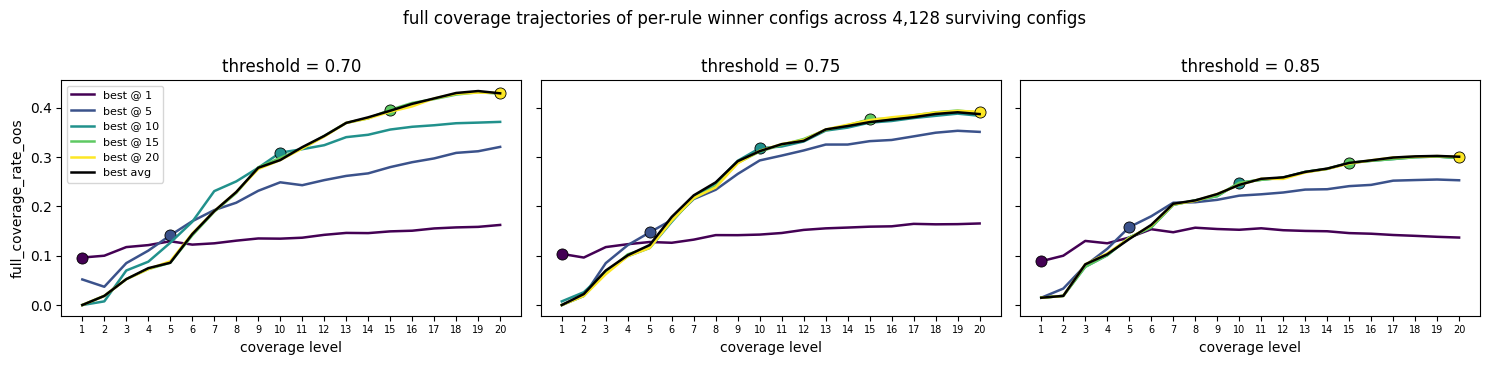


Winner configs per (threshold, rule):
 threshold      rule s1_family s1_exposure_mode                                                               s1_cov s2_family s2_exposure_mode                                                               s2_cov  bulk_family bulk_exposure_mode                                                               bulk_cov  tail_family tail_exposure_mode                                                                tail_cov
      0.70  best @ 1     logit             free  {"basin": true, "is_island": true, "sdi": true, "wind_speed": true}     logit             free {"basin": true, "is_island": false, "sdi": true, "wind_speed": true} scaled_logit               free {"basin": false, "is_island": false, "sdi": true, "wind_speed": false}      weibull               free   {"basin": false, "is_island": true, "sdi": true, "wind_speed": false}
      0.70  best @ 5     logit             free {"basin": true, "is_island": false, "sdi": true, "wind_speed": true}     

In [31]:
winner_records = H.threshold_winner_panels(df_oos)
plt.show()

print('\nWinner configs per (threshold, rule):')
print(winner_records.to_string(index=False))

## Per-row diagnostics — `mid` reconstruction

`dh_results.parquet` stores spec attributes (family, exposure_mode, cov)
but not the MD5 model_id used as the filename prefix in
`model_predictions/`. Rebuild it once via a lookup against the refined
manifest, then attach as a `mid` column on `df_oos`.

The refined-final round reused the refined fits, so the right manifest
is the one at `01-refined/20260517/manifest.json` (set above as
`MANIFEST_PATH`).

In [32]:
import json
from idd_tc_mortality.cache import model_id as compute_model_id

manifest = json.loads(MANIFEST_PATH.read_text())

# Build a lookup: (component, threshold, family, exposure_mode, cov_str) -> full spec dict.
# threshold is None for s1. cov_str is the JSON of covariate_combo with sort_keys=True.
spec_lookup: dict[tuple, dict] = {}
for cid, spec in manifest.items():
    if not isinstance(spec, dict):
        continue
    if spec.get('fold_tag', 'is') != 'is':
        continue
    cov_str = json.dumps(spec.get('covariate_combo', {}), sort_keys=True)
    key = (
        spec.get('component'),
        spec.get('threshold_quantile'),  # None for s1
        spec.get('family'),
        spec.get('exposure_mode'),
        cov_str,
    )
    spec_lookup[key] = spec


def _row_to_mid(row: pd.Series) -> str:
    """Look up the 4 component specs for this DH row, compute the model_id hash."""
    q = row['threshold_quantile']
    s1 = spec_lookup[('s1',   None, row['s1_family'],   row['s1_exposure_mode'],   row['s1_cov'])]
    s2 = spec_lookup[('s2',   q,    row['s2_family'],   row['s2_exposure_mode'],   row['s2_cov'])]
    bk = spec_lookup[('bulk', q,    row['bulk_family'], row['bulk_exposure_mode'], row['bulk_cov'])]
    tl = spec_lookup[('tail', q,    row['tail_family'], row['tail_exposure_mode'], row['tail_cov'])]
    return compute_model_id(s1, s2, bk, tl)


df_oos['mid'] = df_oos.apply(_row_to_mid, axis=1)
print(f'mid attached. {df_oos["mid"].nunique()} unique mids across {len(df_oos)} configs.')

# Sanity check: at least one mid's files should exist on disk.
test_mid = df_oos['mid'].iloc[0]
is_path  = MODEL_PRED_DIR / f'{test_mid}_insample_predictions.parquet'
print(f'sample IS pred file exists: {is_path.exists()} ({is_path.name})')


mid attached. 4128 unique mids across 4128 configs.
sample IS pred file exists: True (00071160522ee0e5ed05d0123d425cec_insample_predictions.parquet)


## Per-config prediction loader

Each config in the refined-final pool has 6 per-row prediction parquets:
- 1 IS  (`<mid>_insample_predictions.parquet`)
- 5 OOS seeds (`<mid>_oos_seed{0..4}_predictions.parquet`)

The loaders below join each prediction frame back to `input.parquet` by
row position so the storm/year/location metadata travels alongside
`predicted_rate`.

In [33]:
# Aliased to match the loader's expectation.
obs = data

def _join_input(pred_df: pd.DataFrame) -> pd.DataFrame:
    """Attach input.parquet's metadata columns to a per-row prediction frame."""
    if len(pred_df) != len(obs):
        raise ValueError(
            f'prediction row count {len(pred_df)} != input row count {len(obs)}'
        )
    out = obs.copy()
    out['predicted_rate'] = pred_df['predicted_rate'].values
    for col in ('heldout_fold_tag', 'threshold_rate', 'fold_tag'):
        if col in pred_df.columns:
            out[col] = pred_df[col].values
    return out


def load_is_pred(mid: str) -> pd.DataFrame:
    p = MODEL_PRED_DIR / f'{mid}_insample_predictions.parquet'
    return _join_input(pd.read_parquet(p))


def load_oos_pred(mid: str) -> pd.DataFrame:
    """Load all 5 OOS-seed predictions, joined to input metadata, with `seed` col."""
    frames = []
    for seed in range(5):
        p = MODEL_PRED_DIR / f'{mid}_oos_seed{seed}_predictions.parquet'
        if not p.exists():
            continue
        joined = _join_input(pd.read_parquet(p))
        joined['seed'] = seed
        frames.append(joined)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


## Drop-top-N trimmed calibration ratio

For every config in the post-cull pool, recompute the obs/pred ratio
after dropping the top-N storms by observed deaths. Sweep N ∈
{0, 5, 10, 25}. Three column families produced:

- `trim_n=*_is`         — IS ratio per N
- `trim_n=*_oos_mean`   — OOS ratio, mean across 5 seeds
- `trim_n=*_oos_median` — OOS ratio, median across 5 seeds

A config whose `trim_n=0` is near 1 but `trim_n=5` is far from 1 (or
vice versa) is exposed as either mega-event-only or bulk-only
calibrated. We want configs that stay near 1 across the N sweep.

In [34]:
# Trimmed-ratio sweep over the post-cull pool. Rewritten 2026-07-20 for the
# 4,608-config grid: read each config's 6 parquets once (June version re-read
# them per N), build the per-storm table once per (config, seed) and slice per
# N, and fan configs over a process pool — the pandas work is GIL-bound, so
# threads don't scale here. Measured ~1-2 min for ~3,800 configs.
from concurrent.futures import ProcessPoolExecutor, as_completed

N_SWEEP = [0, 5, 10, 25]
N_WORKERS = 12


def _per_storm(pred_df: pd.DataFrame) -> pd.DataFrame:
    """Per-storm observed vs predicted deaths, sorted by observed desc."""
    pred_df = pred_df.assign(pred_deaths=pred_df['predicted_rate'] * pred_df['exposed'])
    return (pred_df.groupby('storm_id', as_index=False)
            .agg(obs=('deaths', 'sum'), pred=('pred_deaths', 'sum'))
            .sort_values('obs', ascending=False))


def _trimmed(per_storm: pd.DataFrame, drop_top_n: int) -> float:
    keep = per_storm.iloc[drop_top_n:]
    denom = keep['obs'].sum()
    return float(keep['pred'].sum() / denom) if denom > 0 else float('nan')


def trimmed_ratios_one_config(mid: str) -> list:
    """All N_SWEEP trimmed ratios (IS + per-seed OOS) for one config."""
    is_df = load_is_pred(mid)
    ps_is = None if is_df.empty else _per_storm(is_df)
    oos = load_oos_pred(mid)
    ps_seeds = [] if (oos.empty or 'predicted_rate' not in oos.columns) else [
        _per_storm(sdf) for _, sdf in oos.groupby('seed')
    ]
    rows = []
    for n in N_SWEEP:
        per_seed = [_trimmed(ps, n) for ps in ps_seeds]
        rows.append({
            'mid': mid,
            'drop_top_n': n,
            'ratio_mean':   float(np.nanmean(per_seed)) if per_seed else float('nan'),
            'ratio_median': float(np.nanmedian(per_seed)) if per_seed else float('nan'),
            'ratio_is':     _trimmed(ps_is, n) if ps_is is not None else float('nan'),
        })
    return rows


records = []
mids = df_oos['mid'].tolist()
with ProcessPoolExecutor(max_workers=N_WORKERS) as pool:
    futures = [pool.submit(trimmed_ratios_one_config, m) for m in mids]
    for i, fut in enumerate(as_completed(futures), start=1):
        records.extend(fut.result())
        if i % 500 == 0 or i == len(mids):
            print(f'  trimmed-ratio: {i}/{len(mids)} configs done')


  trimmed-ratio: 500/4128 configs done
  trimmed-ratio: 1000/4128 configs done
  trimmed-ratio: 1500/4128 configs done
  trimmed-ratio: 2000/4128 configs done
  trimmed-ratio: 2500/4128 configs done
  trimmed-ratio: 3000/4128 configs done
  trimmed-ratio: 3500/4128 configs done
  trimmed-ratio: 4000/4128 configs done
  trimmed-ratio: 4128/4128 configs done


In [35]:
recs = pd.DataFrame(records)

trim_df_mean   = recs.pivot(index='mid', columns='drop_top_n', values='ratio_mean')
trim_df_median = recs.pivot(index='mid', columns='drop_top_n', values='ratio_median')
trim_df_is     = recs.pivot(index='mid', columns='drop_top_n', values='ratio_is')

trim_df_mean.columns   = [f'trim_n={n}_oos_mean'   for n in trim_df_mean.columns]
trim_df_median.columns = [f'trim_n={n}_oos_median' for n in trim_df_median.columns]
trim_df_is.columns     = [f'trim_n={n}_is'         for n in trim_df_is.columns]

# Merge all three column families onto df_oos by mid.
df_oos = (df_oos
    .merge(trim_df_is,     left_on='mid', right_index=True, how='left')
    .merge(trim_df_mean,   left_on='mid', right_index=True, how='left')
    .merge(trim_df_median, left_on='mid', right_index=True, how='left')
)

trim_df = trim_df_median   # canonical: matches the median-aggregation of the screening gate
print(f'Trim columns merged onto df_oos. Total cols now: {df_oos.shape[1]}')


Trim columns merged onto df_oos. Total cols now: 145


## IS / OOS divergence

For each config and each N, `is_oos_ratio_n=*` = `trim_n=*_is` /
`trim_n=*_oos_median`. Close to 1 = IS calibration carries to OOS
without surprises. Far from 1 = the config calibrates IS by being
right on the storms it overfits to, and that doesn't generalise.

Reported per-config:
- `is_oos_max_log_dev`  — max |log(is/oos)| across the N sweep
- `is_oos_mean_log_dev` — mean |log(is/oos)| across the N sweep

In [36]:
for n in N_SWEEP:
    df_oos[f'is_oos_ratio_n={n}'] = (
        df_oos[f'trim_n={n}_is'] / df_oos[f'trim_n={n}_oos_median']
    )

ratio_cols = [f'is_oos_ratio_n={n}' for n in N_SWEEP]
df_oos['is_oos_max_log_dev']  = np.abs(np.log(df_oos[ratio_cols])).max(axis=1)
df_oos['is_oos_mean_log_dev'] = np.abs(np.log(df_oos[ratio_cols])).mean(axis=1)

# Same diagnostic on the trim-OOS-median itself (max |log(trim_median)| across N).
log_dev = np.abs(np.log(df_oos[[f'trim_n={n}_oos_median' for n in N_SWEEP]]))
df_oos['oos_median_max_log_dev']  = log_dev.max(axis=1)
df_oos['oos_median_mean_log_dev'] = log_dev.mean(axis=1)
print('IS/OOS divergence columns attached.')


IS/OOS divergence columns attached.


In [37]:
df_oos['trim_n=25_oos_median'].max()

np.float64(4.839787470167824)

## Pick your own metrics

The 13-metric `DEFAULT_METRICS` is just a starting point. Edit the dict
below — comment / uncomment lines — to define the set used downstream.
Both the Kendall heatmap and the ranking step use whatever you set as
`metrics_present` and `calib_present` here.

Direction:
- `'lower'`  → smaller is better
- `'higher'` → larger is better
- `'calib'`  → closer to 1.0 is better (handled separately by the ranking API)

In [38]:
metrics_to_use = {
    # ---- S1 (binary: P(deaths >= 1)) ----
    's1_auroc_oos':                  'higher',
    # 's1_brier_oos':                'lower',
    # 's1_fpr_oos':                  'lower',
    # 's1_fnr_oos':                  'lower',

    # ---- S2 (binary: P(rate >= thresh | deaths >= 1)) ----
    's2_auroc_oos':                  'higher',
    # 's2_brier_oos':                'lower',

    # ---- Bulk (regression on rate < thresh) ----
    'bulk_mae_rate_oos':             'lower',
    # 'bulk_rmse_rate_oos':          'lower',
    # 'bulk_cor_rate_oos':           'higher',

    # ---- Tail (regression on rate >= thresh) ----
    # 'tail_mae_rate_oos':             'lower',
    # 'tail_rmse_rate_oos':          'lower',
    # 'tail_cor_rate_oos':           'higher',

    # ---- Full (unconditional E[rate], applies to every row) ----
    'full_mae_rate_oos':             'lower',
    # 'full_rmse_rate_oos':            'lower',
    # 'full_cor_rate_oos':             'higher',
    # 'full_zero_acc_oos':             'higher',
    'full_pred_obs_ratio_oos':       'calib',
    'full_coverage_rate_20_oos':     'higher',
    'full_coverage_count_20_oos':     'higher',

    # ---- Forward (stage-conditional aggregate) ----
    # 'fwd_mae_rate_oos':              'lower',
    #'fwd_pred_obs_ratio_oos':        'calib',
    'fwd_coverage_rate_20_oos':      'higher',
    'fwd_coverage_count_20_oos':      'higher',

    # ---- IS/OOS divergence (diagnostic, not a selection metric) ----
    'trim_n=10_oos_median':         'calib',
    'trim_n=10_is':         'calib',
}

calib_present   = [k for k, v in metrics_to_use.items()
                   if v == 'calib' and k in df_oos.columns]
# metrics_present = {k: v for k, v in metrics_to_use.items()
#                    if v != 'calib' and k in df_oos.columns}
metrics_present = {k: v for k, v in metrics_to_use.items()
                   if k in df_oos.columns}

print(f'Active rank metrics ({len(metrics_present)}):')
for m, d in metrics_present.items():
    print(f'  {m:35s}  {d}')
print(f'\nActive calibration metrics ({len(calib_present)}):')
for c in calib_present:
    print(f'  {c}  (closer to 1.0)')

missing = [k for k in metrics_to_use if k not in df_oos.columns]
if missing:
    print(f'\n[note] {len(missing)} requested metrics not in df_oos (skipped): {missing}')

Active rank metrics (11):
  s1_auroc_oos                         higher
  s2_auroc_oos                         higher
  bulk_mae_rate_oos                    lower
  full_mae_rate_oos                    lower
  full_pred_obs_ratio_oos              calib
  full_coverage_rate_20_oos            higher
  full_coverage_count_20_oos           higher
  fwd_coverage_rate_20_oos             higher
  fwd_coverage_count_20_oos            higher
  trim_n=10_oos_median                 calib
  trim_n=10_is                         calib

Active calibration metrics (3):
  full_pred_obs_ratio_oos  (closer to 1.0)
  trim_n=10_oos_median  (closer to 1.0)
  trim_n=10_is  (closer to 1.0)


## Kendall τ — metric correlation

Rank correlation between metrics on the culled candidate pool. Tightly
correlated metrics (high τ) are redundant for ranking purposes; an
uncorrelated metric adds independent information.

Computing rank correlations on 4,128 configs × 11 metrics


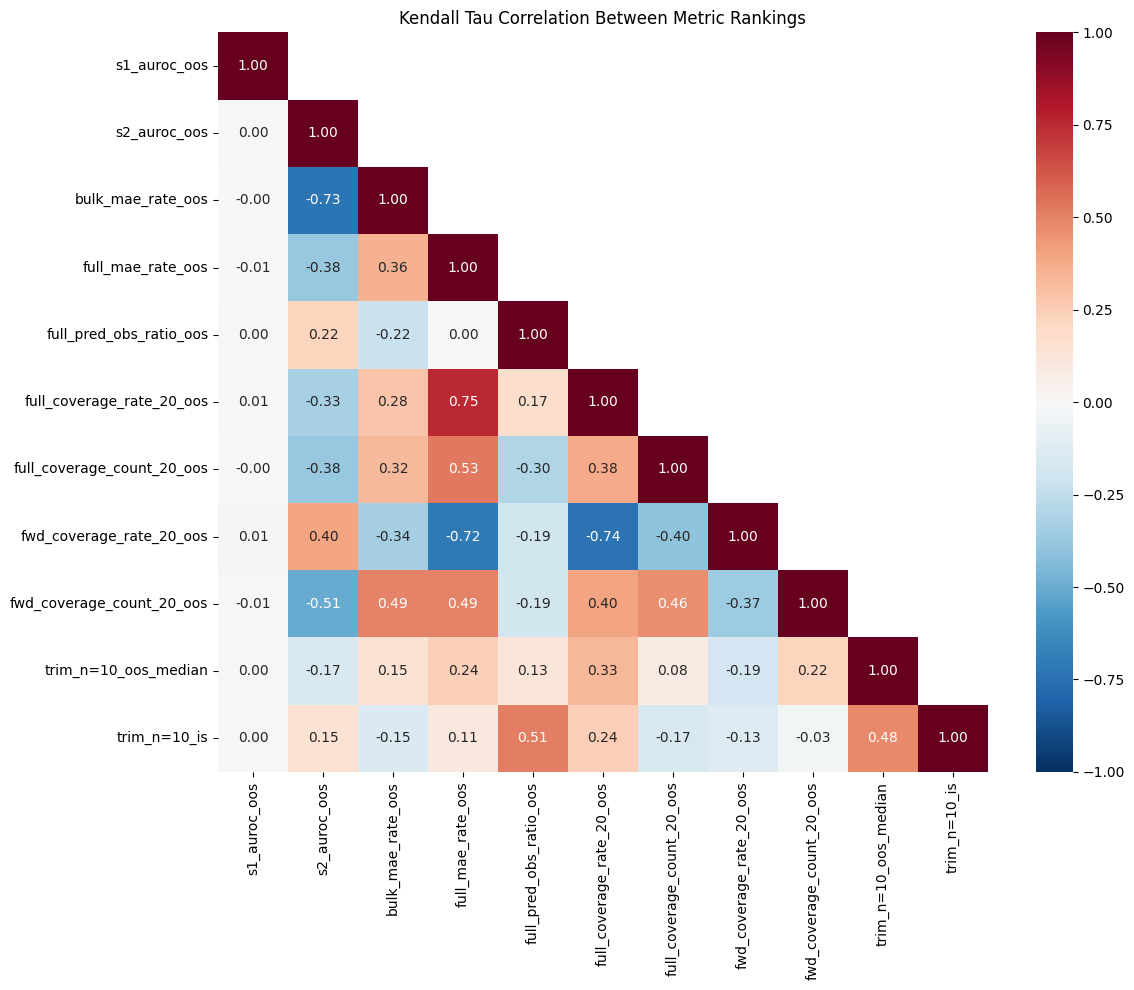


=== Metric Agreement Analysis ===
Average pairwise Kendall tau: 0.024
Pairs with negative correlation: 24
Low agreement. Flat top tier may be aggregation artifact (metric cancellation).
step 1: |τ|=0.755  full_mae_rate_oos (0.315) vs full_coverage_rate_20_oos (0.321)  → drop full_coverage_rate_20_oos
step 2: |τ|=0.731  s2_auroc_oos (0.277) vs bulk_mae_rate_oos (0.254)  → drop s2_auroc_oos
step 3: |τ|=0.716  full_mae_rate_oos (0.247) vs fwd_coverage_rate_20_oos (0.230)  → drop full_mae_rate_oos


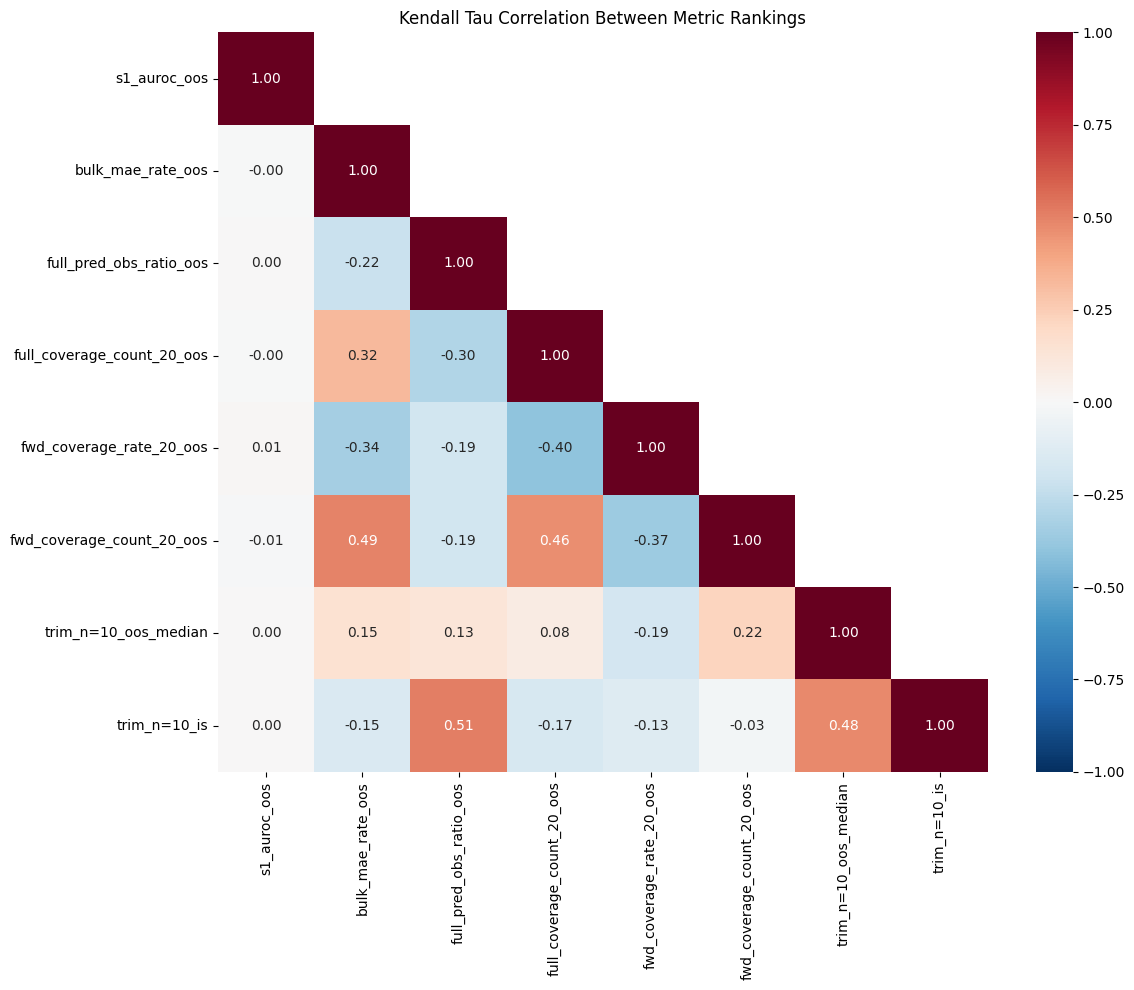


=== Metric Agreement Analysis ===
Average pairwise Kendall tau: 0.007
Pairs with negative correlation: 15
Low agreement. Flat top tier may be aggregation artifact (metric cancellation).


In [39]:
print(f'Computing rank correlations on {len(df_oos):,} configs × '
      f'{len(metrics_present)} metrics')
tau_df = kendall_tau_heatmap(df_oos, metrics_present, calib_present)
metrics_present, prune_log = prune_redundant_metrics(tau_df, metrics_present, threshold=0.7)
tau_df = kendall_tau_heatmap(df_oos, metrics_present, calib_present)
plt.show()

## Winners by method

Borda → TOPSIS → Pareto frontier (first row) → pairwise dominance. Each
method picks one top config; the table compares them on a shared metric set.

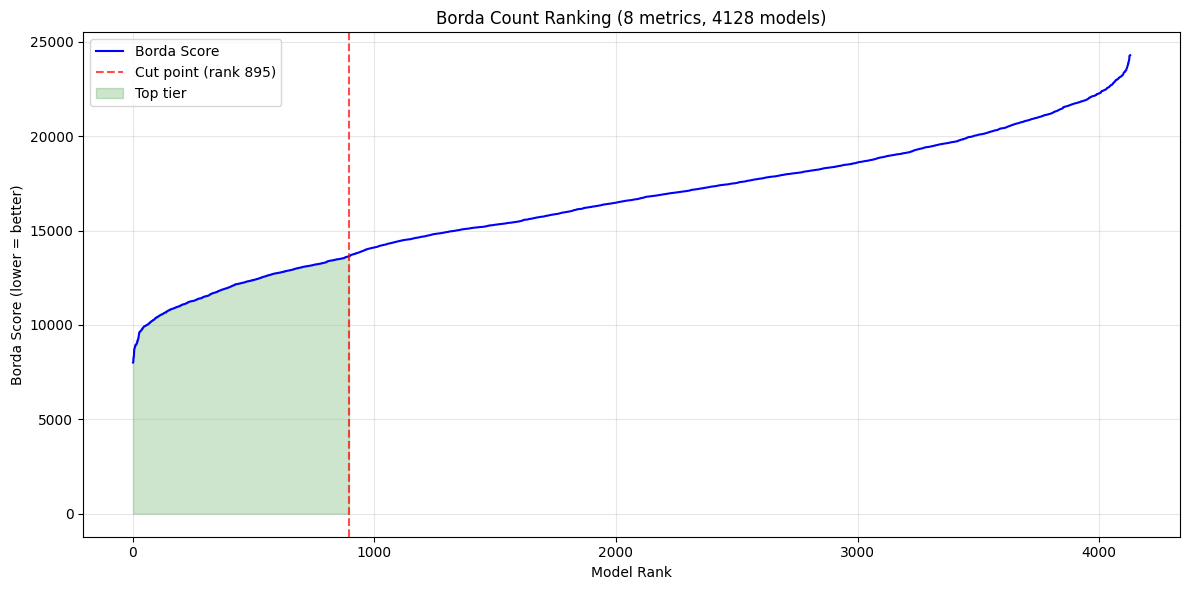


=== Borda Count Summary ===
Total models: 4128
Metrics used: 8
Suggested cutpoint: rank 895 (top 895 models)
Top tier Borda range: 8009.0 - 13632.5
Bottom tier starts at: 13632.5
   threshold_quantile   tail_family tail_exposure_mode bulk_exposure_mode  n_configs  median_rank  min_rank  max_rank  median_score
3                0.70  log_logistic        free+weight        free+weight         33        67.00      24.0     232.0      10072.50
0                0.70           gpd             weight               free         26        69.00       1.0     230.0      10109.00
2                0.70  log_logistic        free+weight               free         48        88.25       9.0     231.0      10303.75
1                0.70           gpd             weight        free+weight         16        98.50      20.0     228.0      10389.00
4                0.70  log_logistic             weight               free         44       101.50      27.0     204.0      10420.25
7                0.75  log_l

In [40]:
borda_df, _    = borda_rank(df_oos,    metrics_present, calib_present)
top_borda_df = borda_df[borda_df['borda_rank'] <= 233].copy()
# table of quantile, tail_family, and covariate configuration
summary_quality = (top_borda_df
    .groupby(['threshold_quantile', 'tail_family', 'tail_exposure_mode', 'bulk_exposure_mode'])
    .agg(
        n_configs=('borda_rank', 'count'),
        median_rank=('borda_rank', 'median'),
        min_rank=('borda_rank', 'min'),
        max_rank=('borda_rank', 'max'),
        median_score=('borda_score', 'median'),
    )
    .reset_index()
    .sort_values('median_rank')
)
print(summary_quality.to_string())

In [41]:
topsis_df, _   = topsis_rank(df_oos,   metrics_present, calib_present, verbose=False)
top_topsis_df = topsis_df[topsis_df['topsis_rank'] <= 200].copy()
summary_quality = (top_topsis_df
    .groupby(['threshold_quantile', 'tail_family', 'tail_exposure_mode', 'bulk_exposure_mode'])
    .agg(
        n_configs=('topsis_rank', 'count'),
        median_rank=('topsis_rank', 'median'),
        min_rank=('topsis_rank', 'min'),
        max_rank=('topsis_rank', 'max'),
        median_score=('topsis_score', 'median'),
    )
    .reset_index()
    .sort_values('median_rank')
)
print(summary_quality.to_string())

    threshold_quantile   tail_family tail_exposure_mode bulk_exposure_mode  n_configs  median_rank  min_rank  max_rank  median_score
0                 0.70           gpd             weight               free         12          6.5       1.0      16.0      0.658107
1                 0.70           gpd             weight        free+weight         12         29.5      12.0      44.0      0.647203
11                0.75       weibull               free        free+weight         35         62.0      13.0     178.0      0.642051
3                 0.70  log_logistic             weight               free         19         82.0      19.0     171.0      0.639675
10                0.75       weibull               free               free         21         90.0      48.0     181.0      0.639282
9                 0.75  log_logistic             weight        free+weight         26        119.5      94.0     194.0      0.637036
8                 0.75  log_logistic             weight              

In [42]:
import json

def decode_cov_columns(df):
    for stage in ['s1', 's2', 'bulk', 'tail']:
        col = f'{stage}_cov'
        for cov in ['basin', 'is_island', 'sdi', 'wind_speed']:
            df[f'{stage}_{cov}'] = df[col].apply(
                lambda x: (x if isinstance(x, dict) else json.loads(x)).get(cov, False)
            )
    return df

top_topsis_df = decode_cov_columns(top_topsis_df)
top_borda_df = decode_cov_columns(top_borda_df)

In [43]:
# Decode cov JSON for each stage
import json

# Get the covariate pattern as a tuple for each stage
for stage in ['s1', 's2', 'bulk', 'tail']:
    covs = ['basin', 'is_island', 'sdi', 'wind_speed']
    top_topsis_df[f'{stage}_pattern'] = top_topsis_df.apply(
        lambda row: '+'.join(c for c in covs if row[f'{stage}_{c}']), axis=1
    )

# Summary by full covariate chain
chain_summary = (top_topsis_df
    .groupby(['s1_pattern', 's2_pattern', 'bulk_pattern', 'tail_pattern'])
    .agg(
        n=('topsis_rank', 'count'),
        median_rank=('topsis_rank', 'median'),
        min_rank=('topsis_rank', 'min'),
    )
    .reset_index()
    .sort_values('median_rank')
)
print(chain_summary.head(20).to_string())

              s1_pattern                      s2_pattern                    bulk_pattern                    tail_pattern  n  median_rank  min_rank
22  basin+sdi+wind_speed  basin+is_island+sdi+wind_speed                             sdi                       basin+sdi  7         20.0       1.0
7   basin+sdi+wind_speed  basin+is_island+sdi+wind_speed                       basin+sdi                       basin+sdi  7         22.0       5.0
16  basin+sdi+wind_speed  basin+is_island+sdi+wind_speed        is_island+sdi+wind_speed                       basin+sdi  6         26.5       4.0
28  basin+sdi+wind_speed  basin+is_island+sdi+wind_speed                  sdi+wind_speed                       basin+sdi  6         29.0       2.0
1   basin+sdi+wind_speed  basin+is_island+sdi+wind_speed  basin+is_island+sdi+wind_speed                       basin+sdi  5         41.0       6.0
57  basin+sdi+wind_speed            basin+sdi+wind_speed                             sdi                       basin+s

In [44]:
# Decode cov JSON for each stage
import json

# Get the covariate pattern as a tuple for each stage
for stage in ['s1', 's2', 'bulk', 'tail']:
    covs = ['basin', 'is_island', 'sdi', 'wind_speed']
    top_borda_df[f'{stage}_pattern'] = top_borda_df.apply(
        lambda row: '+'.join(c for c in covs if row[f'{stage}_{c}']), axis=1
    )

# Summary by full covariate chain
chain_summary = (top_borda_df
    .groupby(['s1_pattern', 's2_pattern', 'bulk_pattern', 'tail_pattern'])
    .agg(
        n=('borda_rank', 'count'),
        median_rank=('borda_rank', 'median'),
        min_rank=('borda_rank', 'min'),
    )
    .reset_index()
    .sort_values('median_rank')
)
print(chain_summary.head(20).to_string())

                        s1_pattern                      s2_pattern              bulk_pattern tail_pattern  n  median_rank  min_rank
41            basin+sdi+wind_speed  basin+is_island+sdi+wind_speed                       sdi    basin+sdi  3        20.00       1.0
77            basin+sdi+wind_speed            basin+sdi+wind_speed                       sdi    basin+sdi  3        30.00       7.0
75            basin+sdi+wind_speed            basin+sdi+wind_speed                       sdi               2        38.50      38.0
63            basin+sdi+wind_speed            basin+sdi+wind_speed      basin+sdi+wind_speed               2        41.00      28.0
81            basin+sdi+wind_speed            basin+sdi+wind_speed            sdi+wind_speed               2        45.50      33.0
29            basin+sdi+wind_speed  basin+is_island+sdi+wind_speed      basin+sdi+wind_speed    basin+sdi  3        47.00       2.0
27            basin+sdi+wind_speed  basin+is_island+sdi+wind_speed      basi

## Picking table

Top configs by `topsis_rank`, with all stage covs / family-exposure
choices and the storm-level diagnostics in one place. Sort and filter
this table interactively — the pick rule is **not** baked in.

Columns of interest for the "no worse than any other" defense:
- `topsis_rank`               — composite rank on the metric pool
- `full_coverage_rate_*_oos`  — uncertainty coverage at chosen level
- `trim_n=*_oos_median`       — calibration robustness across drop-top-N
- `is_oos_max_log_dev`        — IS-to-OOS calibration transfer
- `oos_median_max_log_dev`    — calibration stability across the N sweep


In [45]:
df_oos.head()

,threshold_quantile,s1_family,s1_exposure_mode,s2_family,s2_exposure_mode,bulk_family,bulk_exposure_mode,tail_family,tail_exposure_mode,s1_cov,s2_cov,bulk_cov,tail_cov,s1_brier_oos,s1_auroc_oos,s1_fpr_oos,s1_fnr_oos,s1_predicted_positive_rate_oos,s2_brier_oos,s2_auroc_oos,s2_fpr_oos,s2_fnr_oos,s2_predicted_positive_rate_oos,bulk_mae_rate_oos,bulk_rmse_rate_oos,bulk_cor_rate_oos,bulk_mae_count_oos,bulk_rmse_count_oos,bulk_cor_count_oos,tail_mae_rate_oos,tail_rmse_rate_oos,tail_cor_rate_oos,tail_mae_count_oos,tail_rmse_count_oos,tail_cor_count_oos,fwd_mae_rate_oos,fwd_rmse_rate_oos,fwd_pred_obs_ratio_oos,fwd_coverage_rate_1_oos,fwd_coverage_count_1_oos,...,full_coverage_rate_13_oos,full_coverage_count_13_oos,full_coverage_rate_14_oos,full_coverage_count_14_oos,full_coverage_rate_15_oos,full_coverage_count_15_oos,full_coverage_rate_16_oos,full_coverage_count_16_oos,full_coverage_rate_17_oos,full_coverage_count_17_oos,full_coverage_rate_18_oos,full_coverage_count_18_oos,full_coverage_rate_19_oos,full_coverage_count_19_oos,full_coverage_rate_20_oos,full_coverage_count_20_oos,cor_ts_oos,beta_0_ts_oos,beta_p_ts_oos,mid,trim_n=0_is,trim_n=5_is,trim_n=10_is,trim_n=25_is,trim_n=0_oos_mean,trim_n=5_oos_mean,trim_n=10_oos_mean,trim_n=25_oos_mean,trim_n=0_oos_median,trim_n=5_oos_median,trim_n=10_oos_median,trim_n=25_oos_median,is_oos_ratio_n=0,is_oos_ratio_n=5,is_oos_ratio_n=10,is_oos_ratio_n=25,is_oos_max_log_dev,is_oos_mean_log_dev,oos_median_max_log_dev,oos_median_mean_log_dev
0,0.7,logit,free,logit,free,scaled_logit,free,gpd,weight,"{""basin"": true, ""is_island"": false, ""sdi"": true, ""wind_speed"": true}","{""basin"": true, ""is_island"": false, ""sdi"": true, ""wind_speed"": true}","{""basin"": false, ""is_island"": false, ""sdi"": true, ""wind_speed"": false}","{""basin"": false, ""is_island"": false, ""sdi"": false, ""wind_speed"": false}",0.159786,0.8015,0.108043,0.492552,0.231971,0.094424,0.928725,0.072735,0.270817,0.269754,2.775399e-07,4.407898e-07,0.549017,29.35615,83.930774,0.458483,0.001148,0.004555,-3.513345e-18,1337.077162,8341.380651,0.568469,0.000338,0.002963,0.067178,0.0,0.222222,...,0.326012,0.454335,0.330295,0.468633,0.330326,0.473183,0.338028,0.484038,0.339381,0.487611,0.345303,0.496451,0.350988,0.505534,0.348120,0.513534,0.369419,-24199.551844,30.118431,00071160522ee0e5ed05d0123d425cec,0.106990,0.594147,0.777221,1.129136,0.108258,0.604356,0.790814,1.147300,0.108335,0.603257,0.789595,1.145103,0.987580,0.984899,0.984329,0.986056,0.015796,0.014388,2.222523,0.774916
1,0.7,logit,free,logit,free,scaled_logit,free,gpd,weight,"{""basin"": true, ""is_island"": false, ""sdi"": true, ""wind_speed"": true}","{""basin"": true, ""is_island"": false, ""sdi"": true, ""wind_speed"": true}","{""basin"": false, ""is_island"": false, ""sdi"": true, ""wind_speed"": false}","{""basin"": false, ""is_island"": false, ""sdi"": false, ""wind_speed"": true}",0.159786,0.8015,0.108043,0.492552,0.231971,0.094424,0.928725,0.072735,0.270817,0.269754,2.775399e-07,4.407898e-07,0.549017,29.35615,83.930774,0.458483,0.001149,0.004556,-1.495695e-01,1329.082149,8283.488926,0.574070,0.000338,0.002963,0.071648,0.0,0.266667,...,0.294798,0.450289,0.299732,0.460590,0.312782,0.471679,0.325352,0.478404,0.333628,0.484513,0.345720,0.503132,0.352174,0.520158,0.348496,0.528195,0.415759,-27291.973747,33.391929,843809da0420727226f456c8744f3924,0.106624,0.574352,0.750962,1.090623,0.106241,0.582115,0.761708,1.104874,0.106833,0.581774,0.760863,1.105810,0.998038,0.987243,0.986988,0.986266,0.013829,0.010433,2.236487,0.788010
2,0.7,logit,free,logit,free,scaled_logit,free,gpd,weight,"{""basin"": true, ""is_island"": false, ""sdi"": true, ""wind_speed"": true}","{""basin"": true, ""is_island"": false, ""sdi"": true, ""wind_speed"": true}","{""basin"": false, ""is_island"": false, ""sdi"": true, ""wind_speed"": false}","{""basin"": false, ""is_island"": false, ""sdi"": true, ""wind_speed"": false}",0.159786,0.8015,0.108043,0.492552,0.231971,0.094424,0.928725,0.072735,0.2708

In [46]:
# Attach topsis_rank back onto df_oos (if not already there from earlier cells).
if 'topsis_rank' not in df_oos.columns:
    df_oos = df_oos.merge(
        topsis_df[CONFIG_COLS + ['topsis_rank', 'topsis_score']],
        on=CONFIG_COLS, how='left',
    )

# Columns to show in the picking table.
picking_cols = [
    'mid', 'threshold_quantile',
    's1_family', 's1_exposure_mode', 's1_cov',
    's2_family', 's2_exposure_mode', 's2_cov',
    'bulk_family', 'bulk_exposure_mode', 'bulk_cov',
    'tail_family', 'tail_exposure_mode', 'tail_cov',
    'topsis_rank', 'topsis_score',
    'full_pred_obs_ratio_oos',
    'full_coverage_rate_5_oos', 'full_coverage_rate_10_oos',
    'full_coverage_rate_20_oos',
    'trim_n=0_oos_median',  'trim_n=5_oos_median',
    'trim_n=10_oos_median', 'trim_n=25_oos_median',
    'trim_n=0_is',  'trim_n=5_is', 'trim_n=10_is', 'trim_n=25_is',
    'oos_median_max_log_dev', 'is_oos_max_log_dev',
]
picking_cols = [c for c in picking_cols if c in df_oos.columns]

picking_df = (df_oos[picking_cols]
              .sort_values('topsis_rank')
              .reset_index(drop=True))

# Default view: top 15 by topsis_rank. Re-sort interactively to view by other
# columns (e.g., picking_df.sort_values('oos_median_max_log_dev').head(10)).
TOP_N = 15
print(f'Top {TOP_N} by topsis_rank ({len(picking_df)} configs total):')
print()
print(picking_df.head(TOP_N).round(3).to_string(index=False))


Top 15 by topsis_rank (4128 configs total):

                             mid  threshold_quantile s1_family s1_exposure_mode                                                               s1_cov s2_family s2_exposure_mode                                                               s2_cov  bulk_family bulk_exposure_mode                                                               bulk_cov tail_family tail_exposure_mode                                                              tail_cov  topsis_rank  topsis_score  full_pred_obs_ratio_oos  full_coverage_rate_5_oos  full_coverage_rate_10_oos  full_coverage_rate_20_oos  trim_n=0_oos_median  trim_n=5_oos_median  trim_n=10_oos_median  trim_n=25_oos_median  trim_n=0_is  trim_n=5_is  trim_n=10_is  trim_n=25_is  oos_median_max_log_dev  is_oos_max_log_dev
d29495f3a78f01f9cb72d26b983e15b5                0.70     logit             free {"basin": true, "is_island": false, "sdi": true, "wind_speed": true}     logit             free  {"basin": tru

In [47]:
picking_df['tail_cov'].iloc[0]

'{"basin": true, "is_island": false, "sdi": true, "wind_speed": false}'

In [48]:
no_sdi_in_tail = picking_df[picking_df['tail_cov'] == '{"basin": false, "is_island": false, "sdi": false, "wind_speed": false}'].copy()
no_sdi_in_tail.head()

,mid,threshold_quantile,s1_family,s1_exposure_mode,s1_cov,s2_family,s2_exposure_mode,s2_cov,bulk_family,bulk_exposure_mode,bulk_cov,tail_family,tail_exposure_mode,tail_cov,topsis_rank,topsis_score,full_pred_obs_ratio_oos,full_coverage_rate_5_oos,full_coverage_rate_10_oos,full_coverage_rate_20_oos,trim_n=0_oos_median,trim_n=5_oos_median,trim_n=10_oos_median,trim_n=25_oos_median,trim_n=0_is,trim_n=5_is,trim_n=10_is,trim_n=25_is,oos_median_max_log_dev,is_oos_max_log_dev
119,77278c0360040751bbd992fb2d052c17,0.75,logit,free,"{""basin"": true, ""is_island"": false, ""sdi"": true, ""wind_speed"": true}",logit,free,"{""basin"": true, ""is_island"": false, ""sdi"": true, ""wind_speed"": true}",scaled_logit,free+weight,"{""basin"": false, ""is_island"": false, ""sdi"": true, ""wind_speed"": false}",log_logistic,weight,"{""basin"": false, ""is_island"": false, ""sdi"": false, ""wind_speed"": false}",120.0,0.637007,0.120123,0.139850,0.288722,0.336090,0.120595,0.671903,0.879248,1.278402,0.119105,0.662327,0.865516,1.257877,2.115317,0.016186
123,29f7bfa1099339b26f676e121dc1809e,0.75,logit,free,"{""basin"": true, ""is_island"": false, ""sdi"": true, ""wind_speed"": true}",logit,free,"{""basin"": true, ""is_island"": false, ""sdi"": true, ""wind_speed"": true}",scaled_logit,free,"{""basin"": true, ""is_island"": false, ""sdi"": true, ""wind_speed"": false}",log_logistic,weight,"{""basin"": false, ""is_island"": false, ""sdi"": false, ""wind_speed"": false}",124.0,0.636705,0.116994,0.139850,0.287970,0.328947,0.117524,0.654596,0.856091,1.244375,0.116099,0.645128,0.843042,1.224966,2.141115,0.015720
125,f3e340b573010765c03df21bfc83c2ad,0.75,logit,free,"{""basin"": true, ""is_island"": false, ""sdi"": true, ""wind_speed"": true}",logit,free,"{""basin"": true, ""is_island"": false, ""sdi"": true, ""wind_speed"": true}",scaled_logit,free,"{""basin"": false, ""is_island"": false, ""sdi"": true, ""wind_speed"": false}",log_logistic,weight,"{""basin"": false, ""is_island"": false, ""sdi"": false, ""wind_speed"": false}",126.0,0.636639,0.115874,0.138346,0.287970,0.330075,0.116428,0.648740,0.848339,1.233329,0.115019,0.639403,0.835489,1.214322,2.150482,0.015531
132,5853fe8161f7c2bfb34ec23ce3d46c31,0.75,logit,free,"{""basin"": true, ""is_island"": false, ""sdi"": true, ""wind_speed"": true}",logit,free,"{""basin"": true, ""is_island"": false, ""sdi"": true, ""wind_speed"": true}",scaled_logit,free,"{""basin"": false, ""is_island"": false, ""sdi"": true, ""wind_speed"": true}",log_logistic,weight,"{""basin"": false, ""is_island"": false, ""sdi"": false, ""wind_speed"": false}",133.0,0.636075,0.115810,0.138346,0.285714,0.330827,0.116336,0.648068,0.847423,1.231872,0.114934,0.638816,0.834704,1.213085,2.151274,0.015368
136,c0f44ee324c825ea82c5f04c6596cfef,0.75,logit,free,"{""basin"": true, ""is_island"": false, ""sdi"": true, ""wind_speed"": true}",logit,free,"{""basin"": true, ""is_island"": true, ""sdi"": true, ""wind_speed"": true}",scaled_logit,free,"{""basin"": true, ""is_island"": false, ""sdi"": true, ""wind_speed"": false}",log_logistic,weight,"{""basin"": false, ""is_island"": false, ""sdi"": false, ""wind_speed"": false}",137.0,0.635946,0.116565,0.138346,0.288722,0.327820,0.116725,0.650223,0.850431,1.236171,0.115604,0.642543,0.839607,1.219760,2.147936,0.013365


In [49]:
cols = ['threshold_quantile',
        's1_family','s1_exposure_mode','s1_cov',
        's2_family','s2_exposure_mode','s2_cov',
        'bulk_family','bulk_exposure_mode','bulk_cov',
        'tail_family','tail_exposure_mode','tail_cov']
# This vintage's own top configs by TOPSIS rank. NOTE: a config's `mid` hash
# encodes the data-derived threshold_rate (the absolute rate a quantile maps
# to), so it differs per vintage — the 20260608 winner hashes do NOT appear in
# these grids even for an identical covariate/family config. Always derive the
# winners from this run's ranking, never by hardcoded mid.
import pandas as pd
pd.set_option('display.max_colwidth', None)

TOP_N = 3
mids = df_oos.sort_values('topsis_rank')['mid'].head(TOP_N).tolist()
for rank, m in enumerate(mids, start=1):
    r = df_oos[df_oos.mid == m].iloc[0]
    print(f'#{rank} topsis  mid={m}  q={r["threshold_quantile"]}')
    for c in ['s1_cov', 's2_cov', 'bulk_cov', 'tail_cov']:
        print('   ', c, '=', r[c])


#1 topsis  mid=d29495f3a78f01f9cb72d26b983e15b5  q=0.7
    s1_cov = {"basin": true, "is_island": false, "sdi": true, "wind_speed": true}
    s2_cov = {"basin": true, "is_island": true, "sdi": true, "wind_speed": true}
    bulk_cov = {"basin": false, "is_island": false, "sdi": true, "wind_speed": false}
    tail_cov = {"basin": true, "is_island": false, "sdi": true, "wind_speed": false}
#2 topsis  mid=cd27ab4ef16fbbe1aa036682a8fabed8  q=0.7
    s1_cov = {"basin": true, "is_island": false, "sdi": true, "wind_speed": true}
    s2_cov = {"basin": true, "is_island": true, "sdi": true, "wind_speed": true}
    bulk_cov = {"basin": false, "is_island": false, "sdi": true, "wind_speed": true}
    tail_cov = {"basin": true, "is_island": false, "sdi": true, "wind_speed": false}
#3 topsis  mid=cc753e2e9453abc5f39c351a04382109  q=0.7
    s1_cov = {"basin": true, "is_island": false, "sdi": true, "wind_speed": true}
    s2_cov = {"basin": true, "is_island": true, "sdi": true, "wind_speed": true}
    b

In [50]:
# Alternate view: among the top-N by topsis_rank, re-sort by IS/OOS divergence
# to surface configs whose IS calibration transfers OOS most reliably.
N_SHORTLIST = 25
shortlist = picking_df.head(N_SHORTLIST).copy()
print(f'Among top {N_SHORTLIST} by topsis_rank, sorted by oos_median_max_log_dev:')
print()
print(shortlist
      .sort_values('oos_median_max_log_dev')
      .round(3)
      .to_string(index=False))


Among top 25 by topsis_rank, sorted by oos_median_max_log_dev:

                             mid  threshold_quantile s1_family s1_exposure_mode                                                               s1_cov s2_family s2_exposure_mode                                                               s2_cov  bulk_family bulk_exposure_mode                                                               bulk_cov  tail_family tail_exposure_mode                                                              tail_cov  topsis_rank  topsis_score  full_pred_obs_ratio_oos  full_coverage_rate_5_oos  full_coverage_rate_10_oos  full_coverage_rate_20_oos  trim_n=0_oos_median  trim_n=5_oos_median  trim_n=10_oos_median  trim_n=25_oos_median  trim_n=0_is  trim_n=5_is  trim_n=10_is  trim_n=25_is  oos_median_max_log_dev  is_oos_max_log_dev
f315cc9067ee5c9180a7ecf024a06831                0.70     logit             free {"basin": true, "is_island": false, "sdi": true, "wind_speed": true}     logit            

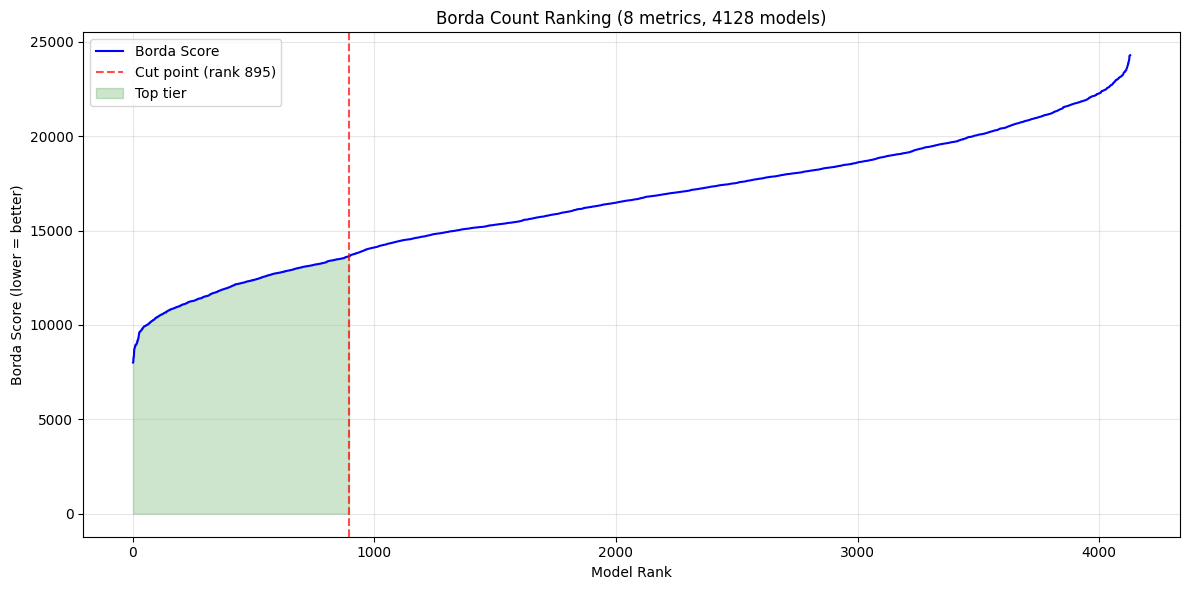


=== Borda Count Summary ===
Total models: 4128
Metrics used: 8
Suggested cutpoint: rank 895 (top 895 models)
Top tier Borda range: 8009.0 - 13632.5
Bottom tier starts at: 13632.5

=== Pareto Frontier ===
Total models: 4128
Non-dominated: 2540 (61.5%)
Dominated: 1588


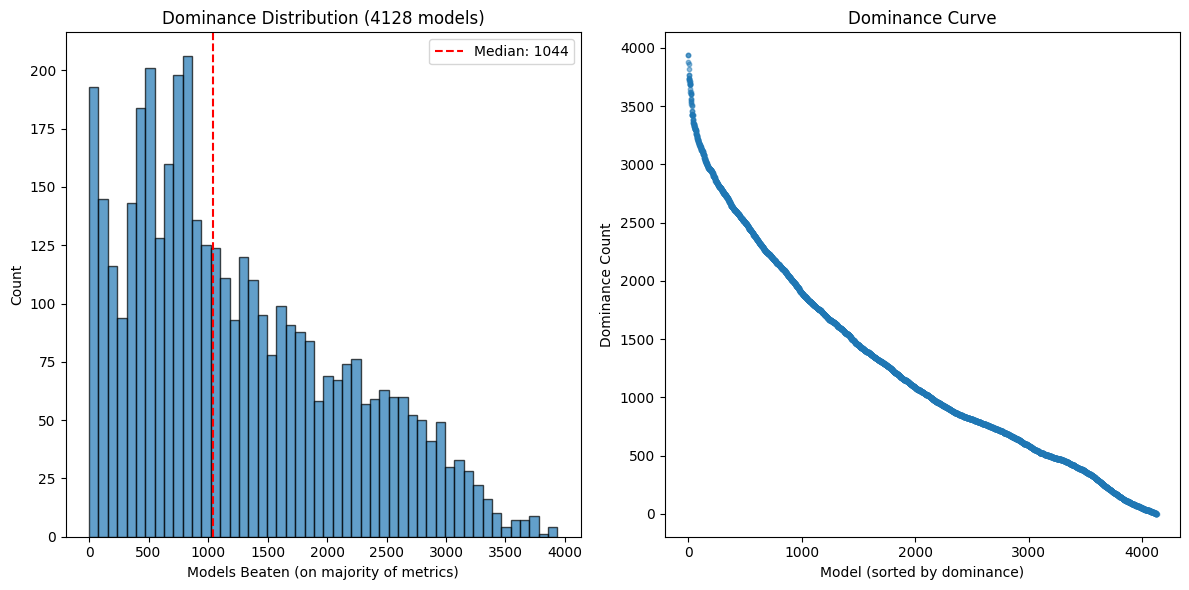


=== Pairwise Dominance Summary ===
Models compared: 4128
Metrics used: 8
Max dominance: 3937 / 4127 models beaten
Median dominance: 1044

Top 10 most dominant models:
   dominance_rank  dominance_count  dominance_pct  threshold_quantile s1_family s1_exposure_mode s2_family s2_exposure_mode   bulk_family bulk_exposure_mode   tail_family tail_exposure_mode                                                                s1_cov                                                                s2_cov                                                                bulk_cov                                                                tail_cov
0             1.5             3937      95.396172                 0.7     logit             free     logit             free  scaled_logit               free           gpd             weight  {"basin": true, "is_island": false, "sdi": true, "wind_speed": true}   {"basin": true, "is_island": true, "sdi": true, "wind_speed": true}  {"basin": false, "is_island

In [51]:
borda_df, _    = borda_rank(df_oos,    metrics_present, calib_present)
topsis_df, _   = topsis_rank(df_oos,   metrics_present, calib_present, verbose=False)
pareto_df      = pareto_frontier(df_oos, metrics_present, calib_present)
dominance_df   = pairwise_dominance_summary(df_oos, metrics_present, calib_present)

winners = {
    'borda':              borda_df.iloc[0],
    'topsis':             topsis_df.iloc[0],
    'pareto_first':       pareto_df.iloc[0],
    'pairwise_dominance': dominance_df.iloc[0],
}
show_cols = [c for c in CONFIG_COLS if c in df_oos.columns] + [
    'full_mae_rate_oos', 'full_cor_rate_oos',
    'full_pred_obs_ratio_oos', 'full_coverage_rate_10_oos',
    'fwd_mae_rate_oos', 'fwd_coverage_rate_10_oos',
    's1_auroc_oos',
]


In [52]:
show_cols = [c for c in show_cols if c in df_oos.columns]
winners_df = pd.DataFrame({k: w[show_cols] for k, w in winners.items()}).T

def _active(j):
    return ','.join(k for k, v in json.loads(j).items() if v) or '∅'
for c in ('s1_cov', 's2_cov', 'bulk_cov', 'tail_cov'):
    if c in winners_df.columns:
        winners_df[c] = winners_df[c].map(_active)
winners_df

,threshold_quantile,s1_family,s1_exposure_mode,s2_family,s2_exposure_mode,bulk_family,bulk_exposure_mode,tail_family,tail_exposure_mode,s1_cov,s2_cov,bulk_cov,tail_cov,full_mae_rate_oos,full_cor_rate_oos,full_pred_obs_ratio_oos,full_coverage_rate_10_oos,fwd_mae_rate_oos,fwd_coverage_rate_10_oos,s1_auroc_oos
borda,0.7,logit,free,logit,free,scaled_logit,free,gpd,weight,"basin,sdi,wind_speed","basin,is_island,sdi,wind_speed",sdi,"basin,sdi",0.000105,-0.003222,0.151373,0.269173,0.000338,0.142169,0.8015
topsis,0.7,logit,free,logit,free,scaled_logit,free,gpd,weight,"basin,sdi,wind_speed","basin,is_island,sdi,wind_speed",sdi,"basin,sdi",0.000105,-0.003222,0.151373,0.269173,0.000338,0.142169,0.8015
pareto_first,0.7,logit,free,logit,free,scaled_logit,free,gpd,weight,"basin,sdi,wind_speed","basin,sdi,wind_speed",sdi,"basin,is_island,sdi,wind_speed",0.000105,-0.002153,0.150625,0.275188,0.000338,0.115663,0.8015
pairwise_dominance,0.7,logit,free,logit,free,scaled_logit,free,gpd,weight,"basin,sdi,wind_speed","basin,is_island,sdi,wind_speed",sdi,"basin,sdi",0.000105,-0.003222,0.151373,0.269173,0.000338,0.142169,0.8015


In [53]:
top_borda_mid = borda_df['mid'].head(5)
top_topsis_mid = topsis_df['mid'].head(5)
top_mid = set(top_borda_mid) | set(top_topsis_mid)
print(top_mid)
print(len(top_mid))

{'cd27ab4ef16fbbe1aa036682a8fabed8', 'd29495f3a78f01f9cb72d26b983e15b5', 'cc753e2e9453abc5f39c351a04382109', 'd5936f989c7fc92775372ee3bd13e3d3', '6da39886d01abecc7e77c32f24edec90'}
5


In [54]:
topsis_df.head(5)

,threshold_quantile,s1_family,s1_exposure_mode,s2_family,s2_exposure_mode,bulk_family,bulk_exposure_mode,tail_family,tail_exposure_mode,s1_cov,s2_cov,bulk_cov,tail_cov,s1_brier_oos,s1_auroc_oos,s1_fpr_oos,s1_fnr_oos,s1_predicted_positive_rate_oos,s2_brier_oos,s2_auroc_oos,s2_fpr_oos,s2_fnr_oos,s2_predicted_positive_rate_oos,bulk_mae_rate_oos,bulk_rmse_rate_oos,bulk_cor_rate_oos,bulk_mae_count_oos,bulk_rmse_count_oos,bulk_cor_count_oos,tail_mae_rate_oos,tail_rmse_rate_oos,tail_cor_rate_oos,tail_mae_count_oos,tail_rmse_count_oos,tail_cor_count_oos,fwd_mae_rate_oos,fwd_rmse_rate_oos,fwd_pred_obs_ratio_oos,fwd_coverage_rate_1_oos,fwd_coverage_count_1_oos,...,full_coverage_rate_14_oos,full_coverage_count_14_oos,full_coverage_rate_15_oos,full_coverage_count_15_oos,full_coverage_rate_16_oos,full_coverage_count_16_oos,full_coverage_rate_17_oos,full_coverage_count_17_oos,full_coverage_rate_18_oos,full_coverage_count_18_oos,full_coverage_rate_19_oos,full_coverage_count_19_oos,full_coverage_rate_20_oos,full_coverage_count_20_oos,cor_ts_oos,beta_0_ts_oos,beta_p_ts_oos,mid,trim_n=0_is,trim_n=5_is,trim_n=10_is,trim_n=25_is,trim_n=0_oos_mean,trim_n=5_oos_mean,trim_n=10_oos_mean,trim_n=25_oos_mean,trim_n=0_oos_median,trim_n=5_oos_median,trim_n=10_oos_median,trim_n=25_oos_median,is_oos_ratio_n=0,is_oos_ratio_n=5,is_oos_ratio_n=10,is_oos_ratio_n=25,is_oos_max_log_dev,is_oos_mean_log_dev,oos_median_max_log_dev,oos_median_mean_log_dev,topsis_rank,topsis_score
0,0.7,logit,free,logit,free,scaled_logit,free,gpd,weight,"{""basin"": true, ""is_island"": false, ""sdi"": true, ""wind_speed"": true}","{""basin"": true, ""is_island"": true, ""sdi"": true, ""wind_speed"": true}","{""basin"": false, ""is_island"": false, ""sdi"": true, ""wind_speed"": false}","{""basin"": true, ""is_island"": false, ""sdi"": true, ""wind_speed"": false}",0.159786,0.8015,0.108043,0.492552,0.231971,0.094704,0.928304,0.075813,0.275229,0.270483,2.775399e-07,4.407898e-07,0.549017,29.356150,83.930774,0.458483,0.001149,0.004555,-0.023196,1359.323098,8308.014368,0.601708,0.000338,0.002963,0.090333,0.0,0.155556,...,0.316354,0.454155,0.320301,0.464160,0.330516,0.470892,0.338496,0.474336,0.341962,0.484760,0.346640,0.497628,0.346992,0.508647,0.269119,-7901.755270,11.497423,d29495f3a78f01f9cb72d26b983e15b5,0.141134,0.765548,0.996563,1.427202,0.151373,0.837203,1.091533,1.543470,0.153338,0.843430,1.096689,1.560956,0.920411,0.907660,0.908701,0.914313,0.096885,0.091285,1.875109,0.645745,1.0,0.663803
1,0.7,logit,free,logit,free,scaled_logit,free,gpd,weight,"{""basin"": true, ""is_island"": false, ""sdi"": true, ""wind_speed"": true}","{""basin"": true, ""is_island"": true, ""sdi"": true, ""wind_speed"": true}","{""basin"": false, ""is_island"": false, ""sdi"": true, ""wind_speed"": true}","{""basin"": true, ""is_island"": false, ""sdi"": true, ""wind_speed"": false}",0.159786,0.8015,0.108043,0.492552,0.231971,0.094704,0.928304,0.075813,0.275229,0.270483,2.780978e-07,4.420274e-07,0.545928,29.342849,83.841361,0.463976,0.001149,0.004555,-0.023196,1359.323098,8308.014368,0.601708,0.000338,0.002963,0.090479,0.0,0.155556,...,0.315818,0.456300,0.320301,0.463659,0.330516,0.472770,0.338938,0.475664,0.341962,0.484342,0.347036,0.496838,0.346992,0.509023,0.269531,-7934.288568,11.527202,cd27ab4ef16fbbe1aa036682a8fabed8,0.140985,0.764570,0.995258,1.425148,0.151248,0.836367,1.090390,1.541656,0.153206,0.842902,1.095917,1.558479,0.920229,0.907069,0.908151,0.914448,0.097537,0.091613,1.875970,0.645544,2.0,0.662627
2,0.7,logit,free,logit,free,scaled_logit,free,gpd,weight,"{""basin"": true, ""is_island"": false, ""sdi"": true, ""wind_speed"": true}","{""basin"": true, ""is_island"": true, ""sdi"": true, ""wind_speed"": true}","{""basin"": true, ""is_island"": false, ""sdi"": true, ""wind_speed"": true}","{""basin"": true, ""is_island"": false, ""sdi"": true, ""wind_speed"": false}",0.159786,0.8015,0.108043,0.492552,0.231971,0.094704,0.928304,0.075813,0.275229,0.270483,2.757044e-07,4.379234e-07,0.556217,29.488198

In [55]:
import json

def decode_cov_columns(df):
    df = df.copy()
    for stage in ['s1', 's2', 'bulk', 'tail']:
        col = f'{stage}_cov'
        for cov in ['basin', 'is_island', 'sdi', 'wind_speed']:
            df[f'{stage}_{cov}'] = df[col].apply(
                lambda x: (x if isinstance(x, dict) else json.loads(x)).get(cov, False)
            )
    return df

covs = ['basin', 'is_island', 'sdi', 'wind_speed']
df_oos = decode_cov_columns(df_oos)
for stage in ['s1', 's2', 'bulk', 'tail']:
    df_oos[f'{stage}_pattern'] = df_oos.apply(
        lambda row: '+'.join(c for c in covs if row[f'{stage}_{c}']) or '∅',
        axis=1,
    )


In [56]:
top_df = df_oos[df_oos['mid'].isin(top_mid)].copy()
top_df['mid_short'] = top_df['mid'].str[:8]


display_cols = [
    'mid_short', 'topsis_rank', 'topsis_score',
    'threshold_quantile',
    's1_family',   's1_exposure_mode',   's1_pattern',
    's2_family',   's2_exposure_mode',   's2_pattern',
    'bulk_family', 'bulk_exposure_mode', 'bulk_pattern',
    'tail_family', 'tail_exposure_mode', 'tail_pattern',
    'full_pred_obs_ratio_oos',
    'full_coverage_rate_5_oos', 'full_coverage_rate_10_oos', 'full_coverage_rate_20_oos',
    'trim_n=0_oos_median', 'trim_n=5_oos_median', 'trim_n=10_oos_median', 'trim_n=25_oos_median',
    'trim_n=0_is',  'trim_n=5_is',  'trim_n=10_is',  'trim_n=25_is',
    'oos_median_max_log_dev', 'is_oos_max_log_dev',
]
display_cols = [c for c in display_cols if c in top_df.columns]

top_df_view = (
    top_df[display_cols]
    .sort_values('topsis_rank')
    .reset_index(drop=True)
    .round(3)
)

# Set display width for the notebook so it doesn't wrap awkwardly.
import pandas as pd
with pd.option_context('display.max_columns', None,
                       'display.width', 220,
                       'display.max_colwidth', 30):
    print(top_df_view.to_string(index=False))


mid_short  topsis_rank  topsis_score  threshold_quantile s1_family s1_exposure_mode           s1_pattern s2_family s2_exposure_mode                     s2_pattern  bulk_family bulk_exposure_mode             bulk_pattern tail_family tail_exposure_mode tail_pattern  full_pred_obs_ratio_oos  full_coverage_rate_5_oos  full_coverage_rate_10_oos  full_coverage_rate_20_oos  trim_n=0_oos_median  trim_n=5_oos_median  trim_n=10_oos_median  trim_n=25_oos_median  trim_n=0_is  trim_n=5_is  trim_n=10_is  trim_n=25_is  oos_median_max_log_dev  is_oos_max_log_dev
 d29495f3          1.0         0.664                 0.7     logit             free basin+sdi+wind_speed     logit             free basin+is_island+sdi+wind_speed scaled_logit               free                      sdi         gpd             weight    basin+sdi                    0.151                     0.128                      0.269                      0.347                0.153                0.843                 1.097               